In [2]:
%load_ext autoreload
%autoreload 2

In [8]:
import pandas as pd
from go_ml.eval_utils import filter_annot_df
from go_ml.eval_utils import (load_msa_dict, gen_pssm_mat, get_pssm_entropy, 
                              gen_annot_mat, gen_seq_len_mask, mean_reciprocal_rank, 
                              mean_reciprocal_rank_mat, mean_auc, top_30_score, roc_average)

In [ ]:
msa_root = '../msa_benchmark/uniref_msa'
csa_dir, llps_dir, elms_dir = f'{msa_root}/csa_msa_output', f'{msa_root}/llps_msa_output', f'{msa_root}/elms_msa_output'
data_root = '../gen_datasets/datasets'
csa_df = filter_annot_df(pd.read_csv(f'{data_root}/csa_annot.csv', sep='\t'))
llps_df = filter_annot_df(pd.read_csv(f'{data_root}/llps_dataset.csv', sep='\t'))
elms_df = filter_annot_df(pd.read_csv(f'{data_root}/elms_dataset.csv', sep='\t'))

In [ ]:
def build_pssm_mat(annot_df, msa_dir):
    msa_dict = load_msa_dict(annot_df['UniprotID'], msa_dir)
    pssm_mat = gen_pssm_mat(annot_df['UniprotID'], msa_dict, max_len=850)
    return pssm_mat

import pickle
ds_labels = ['csa', 'llps', 'elms']
for ds_label, msa_dir, annot_df in zip(ds_labels, [csa_dir, llps_dir, elms_dir], [csa_df, llps_df, elms_df]):
    pssm_mat = build_pssm_mat(annot_df, msa_dir)
    annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
    seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
    pssm_entropy = get_pssm_entropy(pssm_mat, seq_len_mask)
    with open(f'eval_files/{ds_label}_msa.pkl', 'wb') as f:
        pickle.dump({'UniprotID': annot_df['UniprotID'], 'pssm': pssm_mat, 
                     'seq_len_mask': seq_len_mask, 'pssm_entropy': pssm_entropy}, f)
    print(f'MSA Directory: {msa_dir}')

MSA Directory: ../msa_benchmark/uniref_msa/csa_msa_output
MSA Directory: ../msa_benchmark/uniref_msa/llps_msa_output
MSA Directory: ../msa_benchmark/uniref_msa/elms_msa_output


In [ ]:
annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
pssm_entropy = get_pssm_entropy(pssm_mat, seq_len_mask)

mrr = mean_reciprocal_rank_mat(3-pssm_entropy, seq_len_mask, annot_mat)
auc, fpr_l, tpr_l = mean_auc(3 - pssm_entropy, seq_len_mask, annot_mat, return_roc=True)
top_30 = top_30_score(3 - pssm_entropy, seq_len_mask, annot_mat)
print(mrr, auc, top_30)
from go_ml.eval_utils import roc_average
mean_fpr_pssm, mean_tpr_pssm = roc_average(fpr_l, tpr_l)

(784,) (784,)
0.04579766421579865 0.7943132998622431 0.4217548803570712


In [25]:
import pickle
with open('bert_logits/csa_logits.pkl', 'rb') as f:
    csa_logits = pickle.load(f)
csa_logits = {k: v.float().numpy() for k, v in csa_logits.items()}
csa_logits = {k: v[:, 4:24] for k, v in csa_logits.items()}
from scipy.special import softmax
bert_map = {k: softmax(v, axis=1) for k, v in csa_logits.items()}

from go_ml.eval_utils import get_bert_entropy, gen_annot_mat, gen_seq_len_mask, gen_bert_mat
annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
bert_mat = gen_bert_mat(annot_df['UniprotID'], bert_map, max_len=850)
bert_entropy = get_bert_entropy(bert_mat, seq_len_mask)

from go_ml.eval_utils import mean_reciprocal_rank, mean_reciprocal_rank_mat, mean_auc, top_30_score
mrr = mean_reciprocal_rank_mat(3-bert_entropy, seq_len_mask, annot_mat)
auc, fpr_l, tpr_l = mean_auc(3 - bert_entropy, seq_len_mask, annot_mat, return_roc=True)
top_30 = top_30_score(3 - bert_entropy, seq_len_mask, annot_mat)
print(mrr, auc, top_30)

mean_fpr_bert, mean_tpr_bert = roc_average(fpr_l, tpr_l)

(784,) (784,)
0.050316160081567946 0.8141316953291989 0.5946500784379686


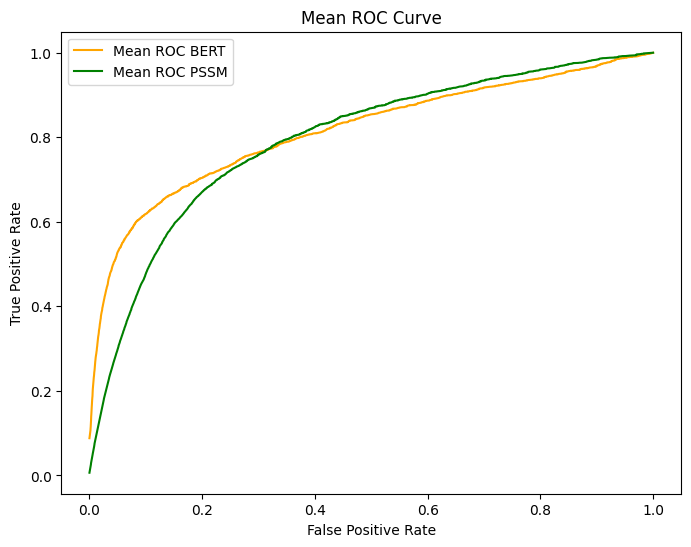

In [28]:
import matplotlib.pyplot as plt
# plt.style.use('seaborn-darkgrid')
plt.figure(figsize=(8, 6))
# plt.plot(mean_fpr, mean_tpr, color='blue', label='Mean ROC')
plt.plot(mean_fpr_bert, mean_tpr_bert, color='orange', label='Mean ROC BERT')
plt.plot(mean_fpr_pssm, mean_tpr_pssm, color='green', label='Mean ROC PSSM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Mean ROC Curve')
plt.legend()

In [10]:
import os
from Bio import SeqIO
def has_seed(msa_path, seed_seq_id):
    sequences = list(SeqIO.parse(msa_path, "fasta"))
    return any(seed_seq_id in record.id for record in sequences)
count = 0
whitelist = []
for prot_id in annot_df['UniprotID']:
    msa_path = os.path.join('../msa_benchmark/uniref_msa/llps_msa_output', f'{prot_id}_homologues_aligned.fasta')
    # print(prot_id)
    if os.path.exists(msa_path):
        if has_seed(msa_path, prot_id):
            count += 1
        else:
            print(f"Missing seed for {prot_id}")
            whitelist.append(prot_id)
            # print(list(SeqIO.parse(msa_path, "fasta")))
print(f"Total sequences with seed: {count}")
print(f"Total sequences without seed: {len(annot_df['UniprotID']) - count}")


Total sequences with seed: 0
Total sequences without seed: 795


In [ ]:
  # Normalize to get probabilities

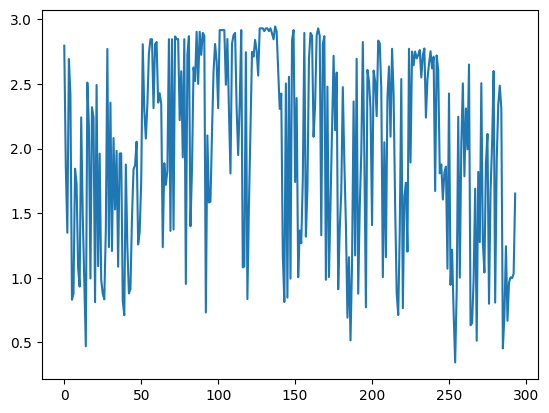

In [20]:
msa_entropy = -np.sum(msa_array * np.log(msa_array + 1e-10), axis=1)  # Add small constant to avoid log(0)
import matplotlib.pyplot as plt
plt.plot(3 - msa_entropy, label='MSA Entropy')

In [34]:
gr_thirty = (sequences_array == 20).mean(axis=0) >= 0.3
print(gr_thirty.mean())

0.5541984732824428


In [ ]:
seed_seq

msa_mat = np.array()

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True,  True, False, False, False, False,
        True,  True,  True,  True, False, False, False, False, False,
        True,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [6]:
sequences_array

array([['-', '-', '-', ..., 'D', '-', 'D'],
       ['-', '-', '-', ..., 'I', '-', 'T'],
       ['-', '-', '-', ..., 'A', '-', 'V'],
       ...,
       ['-', '-', '-', ..., 'A', 'I', '-'],
       ['-', '-', '-', ..., 'E', 'V', '-'],
       ['-', '-', '-', ..., '-', '-', '-']], shape=(310, 655), dtype='<U1')

In [ ]:
msa_dir = "../../data/msa_files/msa"

import numpy as np
def calculate_entropy(sequences):
    # print(sequences.shape)
    num_seq, alignment_length = sequences.shape
    entropies = []

    for i in np.arange(alignment_length):
        column = sequences[:, i]
        if np.sum(column == '-') / num_seq >= 0.3:
            entropies.append(100)
            continue
        column = column[column != '-']   
        values, counts = np.unique(column, return_counts=True)
        p = counts / num_seq
        entropy = -np.sum(p * np.log(p))
        entropies.append(entropy)
    return entropies

,UniprotID,AnnotatedIndices,EnzymeClass,GOTerm,Sequence
0,A0A0F6FBL7,"[14, 83, 197]",5.1.1.13,['GO:0047689'],NaN
1,A0QTN8,"[162, 191, 217, 242, 266, 294, 18420]",5.5.1.1,['GO:0018849'],MKIVAIGAIPFSIPYTKPLRFASGEVHAAEHVLVRVHTDDGIVGVA...
2,A2RJT9,"[43, 130, 57618]",1.3.98.1,['GO:1990663'],MLNTTFANAKFANPFMNASGVHCMTIEDLEELKASQAGAYITKSST...
3,A4XF23,"[147, 159, 210, 212, 236, 262, 283, 339, 402, ...",4.2.1.8,['GO:0008927'],MKITAARVIITCPGRNFVTLKIETDQGVYGIGDATLNGRELSVVAY...
4,A5JTM5,"[64, 86, 90, 114, 137, 145]",3.8.1.7,['GO:0018787'],MYEAIGHRVEDGVAEITIKLPRHRNALSVKAMQEVTDALNRAEEDD...
...,...,...,...,...,...
841,Q9ZAG3,"[53, 55, 99, 101, 132]",3.3.2.8,['GO:0018744'],MTSKIEQPRWASKDSAAGAASTPDEKIVLEFMDALTSNDAAKLIEY...
842,Q9ZF13,"[50, 127, 128, 196, 198, 225, 254]",3.2.1.78,['GO:0016985'],GLHVKNGRLYEANGQEFIIRGVSHPHNWYPQHTQAFADIKSHGANT...
843,Q9ZHG9,"[114, 197, 199, 200, 223, 360, 597326]",4.4.1.35,['GO:0044540'],MADPVNLIPDRHQFPGLANKTYFNFGGQGILPTVALEAITAMYGYL...
844,Q9ZHI0,"[114, 116, 118, 221, 312, 406, 409, 422, 427]",6.5.1.2,['GO:0003911'],MTREEARRRINELRDLIRYHNYRYYVLADPEISDAEYDRLLRELKE...
